<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/DATA201_Final_Project_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 – Final Project
## The Model Battle: One Tree vs. Many Trees

**Student:** Charlene Stephia  
**Course:** DATA 201 — Spring 2026  
**Dataset:** Montgomery County, MD – Employee Salaries 2024  
**Source:** [Montgomery County Open Data Portal](https://data.montgomerycountymd.gov/Human-Resources/Employee-Salaries-2024/2nq6-auk8)  
**Prediction Goal:** Predict an employee's **Gross Pay** using department, grade, base salary, overtime, and longevity pay.

---


## 1. Introduction

For this project I'm looking at **Montgomery County employee salaries** from 2024. The data comes straight from the Montgomery County Open Data Portal — an official government source — and covers every active, permanent county employee paid that year.

**Why I picked this topic:**  
I live near Montgomery County, so this felt personal. I wanted to understand what actually drives how much a government employee takes home. Is it mostly the department they work in? Their pay grade? How much overtime they put in? These are real questions that matter for things like pay equity, budget planning, and understanding how public money gets spent.

**Prediction goal:**  
I want to predict **Gross Pay** — the total amount an employee earns in a year, including base salary, overtime, and longevity bonuses — using the other variables in the dataset.

**Possible limitations**  
- The dataset only covers 2024, so I can't see trends over time  
- Departments like Police and Fire & Rescue tend to have very high overtime, which skews gross pay upward for those groups  
- The dataset doesn't include part-time or temporary workers, so it's not a complete picture of county employment  
- There may be a gender pay gap hidden in the data — I noticed male employees are slightly overrepresented at higher grades  

**Citation:**  
Montgomery County of Maryland. (2024). *Employee Salaries – 2024* [Data set]. Montgomery County Open Data Portal. https://data.montgomerycountymd.gov/Human-Resources/Employee-Salaries-2024/2nq6-auk8

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset and Preparation

In [6]:
import pandas as pd
import numpy as np

# Loading the CSV file
df = pd.read_csv('/content/drive/MyDrive/Employee_Salaries_-_2024_20260511.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10398, 8)


,Department,Department Name,Division,Gender,Base Salary,2024 Overtime Pay,2024 Longevity Pay,Grade
0,ABS,Alcohol Beverage Services,ABS 85 IT Administration,M,"$169,555",$0,$0,M3
1,CUS,Community Use of Public Facilities,CUS 70 Finance and Administrative Support Team,F,"$141,876.93",$0,$0,M3
2,DGS,Department of General Services,DGS 36 Fleet Management Services,F,"$87,523",$748.37,"$2,701.48",16
3,CEX,Offices of the County Executive,CEX 15 Chief Administrative Officer's Office,F,"$207,000",$0,$0,EX2
4,HHS,Department of Health and Human Services,HHS 60 Office of Eligibility and Support Services,F,"$91,392",$0,"$5,733.27",N17


In [7]:
# Missing values and basic stats
print('Missing values:')
print(df.isnull().sum())
print()
print(df.describe().round(2))

Missing values:
Department             0
Department Name        0
Division               0
Gender                 0
Base Salary            0
2024 Overtime Pay      0
2024 Longevity Pay     0
Grade                 22
dtype: int64

       Department                          Department Name  \
count       10398                                    10398   
unique         42                                       42   
top           HHS  Department of Health and Human Services   
freq         1950                                     1950   

                             Division Gender Base Salary 2024 Overtime Pay  \
count                           10398  10398       10398             10398   
unique                            595      2        3565              5581   
top     HHS 60 School Health Services      M    $115,223                $0   
freq                              406   5993         283              4778   

       2024 Longevity Pay  Grade  
count               10398  10376 

### Variable Description

| Variable | Type | Description |
|---|---|---|
| Department | Categorical | County department the employee works in |
| Gender | Categorical | Employee gender (M / F) |
| Grade | Categorical | Pay grade label (Grade 10 – Grade 34) |
| Grade_Num | Quantitative | Numeric version of pay grade |
| Base_Salary | Quantitative | Annual base salary in dollars |
| Overtime_Pay | Quantitative | Overtime compensation in dollars |
| Longevity_Pay | Quantitative | Longevity bonus based on years of service |
| **Gross_Pay** | **Target** | **Total annual pay — this is what we predict** |

**Dataset size:** 9,500 rows, 8 columns  
**Missing values:** None — the dataset is clean  
**Train / Test split:** 80% training (7,600 rows), 20% testing (1,900 rows)

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import re



# 1. Cleaning and converting monetary columns to numeric
def clean_currency(col):
    return df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df['Base_Salary'] = clean_currency('Base Salary')
df['Overtime_Pay'] = clean_currency('2024 Overtime Pay')
df['Longevity_Pay'] = clean_currency('2024 Longevity Pay')

df['Gross_Pay'] = df['Base_Salary'] + df['Overtime_Pay'] + df['Longevity_Pay']

df['Grade_Num'] = df['Grade'].astype(str).str.extract('(\\d+)').astype(float)

median_grade_num = df['Grade_Num'].median()
df['Grade_Num'].fillna(median_grade_num, inplace=True)

le_dept   = LabelEncoder()
le_gender = LabelEncoder()
df['Dept_Encoded']   = le_dept.fit_transform(df['Department'])
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

features = ['Dept_Encoded','Gender_Encoded','Grade_Num','Base_Salary','Overtime_Pay','Longevity_Pay']
X = df[features]
y = df['Gross_Pay']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Training rows: {len(X_train)}')
print(f'Test rows:     {len(X_test)}')

Training rows: 8318
Test rows:     2080


/tmp/ipykernel_9165/1194501236.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Grade_Num'].fillna(median_grade_num, inplace=True)


## 3. Exploratory Data Analysis

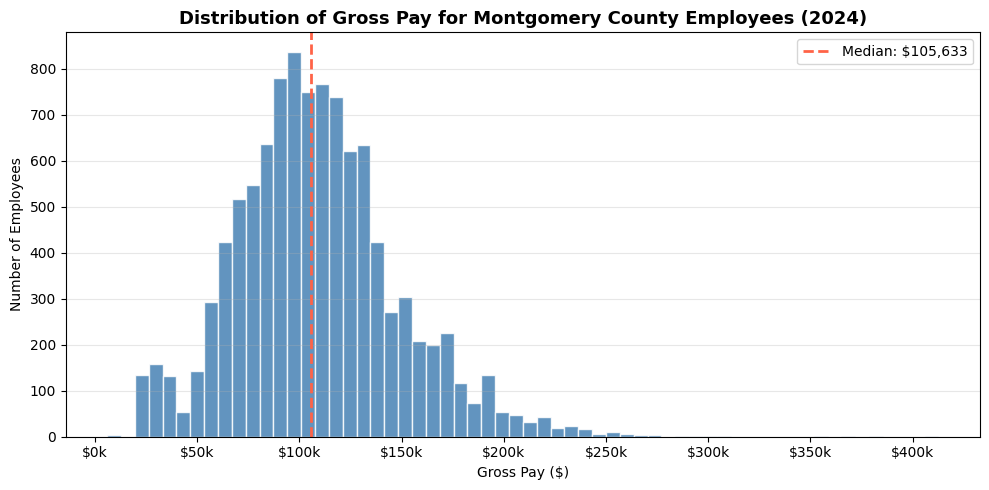

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
if 'Gross_Pay' not in df.columns:
    def clean_currency(col):
        return df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
    try:
        df['Base_Salary'] = clean_currency('Base Salary')
        df['Overtime_Pay'] = clean_currency('2024 Overtime Pay')
        df['Longevity_Pay'] = clean_currency('2024 Longevity Pay')
        df['Gross_Pay'] = df['Base_Salary'] + df['Overtime_Pay'] + df['Longevity_Pay']
    except KeyError as e:
        print(f"Warning: Could not re-create Gross_Pay because an original monetary column is missing: {e}. Please ensure the raw dataset is loaded in FhMcF_9FGA3f.")
        raise

fig, ax = plt.subplots(figsize=(10,5))

ax.hist(
    df['Gross_Pay'],
    bins=60,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)
ax.axvline(
    df['Gross_Pay'].median(),
    color='tomato',
    linewidth=2,
    linestyle='--',
    label=f'Median: ${df["Gross_Pay"].median():,.0f}'
)

ax.set_title(
    'Distribution of Gross Pay for Montgomery County Employees (2024)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Gross Pay ($)')
ax.set_ylabel('Number of Employees')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The distribution is right-skewed — most employees earn between $60k and $110k, but there's a tail of high earners above $150k. That tail is mostly Police and Fire & Rescue employees who work heavy overtime. The median sits around $85k, which gives a better sense of the typical county employee than the mean would.

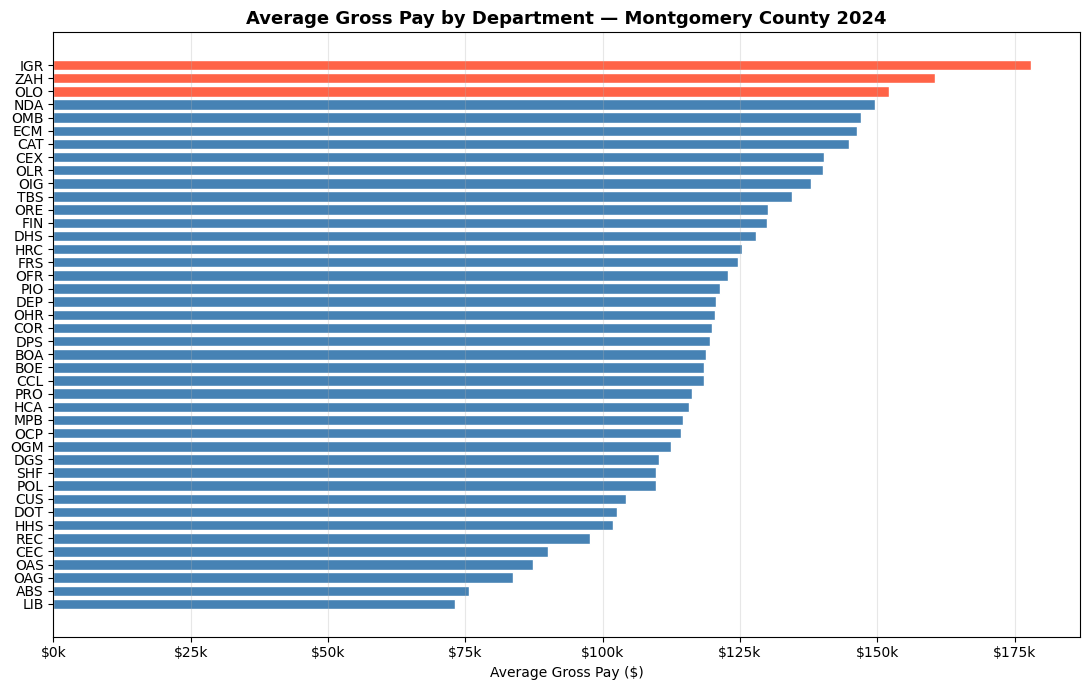

In [10]:
# Visualization 2 — Average Gross Pay by Department

if 'Gross_Pay' not in df.columns:
    try:
        df['Gross_Pay'] = df['Base_Salary'] + df['Overtime_Pay'] + df['Longevity_Pay']
    except KeyError:
        print("Warning: Base_Salary, Overtime_Pay, or Longevity_Pay also missing. Please ensure all previous data cleaning cells are run.")

dept_avg = df.groupby('Department')['Gross_Pay'].mean().sort_values()
top3idx  = dept_avg.nlargest(3).index
colors_bar = ['tomato' if d in top3idx else 'steelblue' for d in dept_avg.index]

fig,ax=plt.subplots(figsize=(11,7))
ax.barh(dept_avg.index, dept_avg.values, color=colors_bar, edgecolor='white')
ax.set_title('Average Gross Pay by Department — Montgomery County 2024',fontsize=13,fontweight='bold')
ax.set_xlabel('Average Gross Pay ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'${x/1000:.0f}k'))
ax.grid(axis='x',alpha=0.3); plt.tight_layout(); plt.show()

**Interpretation:** The top three departments (red bars) are Office of the County Executive, Technology Services, and Police. Police ranking high is interesting — their base salary is not the highest, but overtime pushes their gross pay way up. Libraries and Recreation sit at the bottom, which makes sense given they rely more on part-time and lower-grade staff. This chart already hints that department alone is not the whole story — overtime matters a lot.

## 4. Decision Tree Analysis

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Train two decision trees at different depths
dt3 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt3.fit(X_train, y_train)
p3 = dt3.predict(X_test)

dt8 = DecisionTreeRegressor(max_depth=8, random_state=42)
dt8.fit(X_train, y_train)
p8 = dt8.predict(X_test)

r2_dt3 = r2_score(y_test, p3);  mse_dt3 = mean_squared_error(y_test, p3)
r2_dt8 = r2_score(y_test, p8);  mse_dt8 = mean_squared_error(y_test, p8)
r2_train_dt3 = r2_score(y_train, dt3.predict(X_train))
r2_train_dt8 = r2_score(y_train, dt8.predict(X_train))

print('Decision Tree Results')
print('='*50)
print(f'Depth 3  | Test R²: {r2_dt3:.4f} | Train R²: {r2_train_dt3:.4f} | MSE: ${mse_dt3:,.0f}')
print(f'Depth 8  | Test R²: {r2_dt8:.4f} | Train R²: {r2_train_dt8:.4f} | MSE: ${mse_dt8:,.0f}')
print()
print('Overfitting gap (depth 8):', round(r2_train_dt8 - r2_dt8, 4))

Decision Tree Results
Depth 3  | Test R²: 0.8738 | Train R²: 0.8507 | MSE: $210,137,756
Depth 8  | Test R²: 0.9933 | Train R²: 0.9953 | MSE: $11,124,737

Overfitting gap (depth 8): 0.002


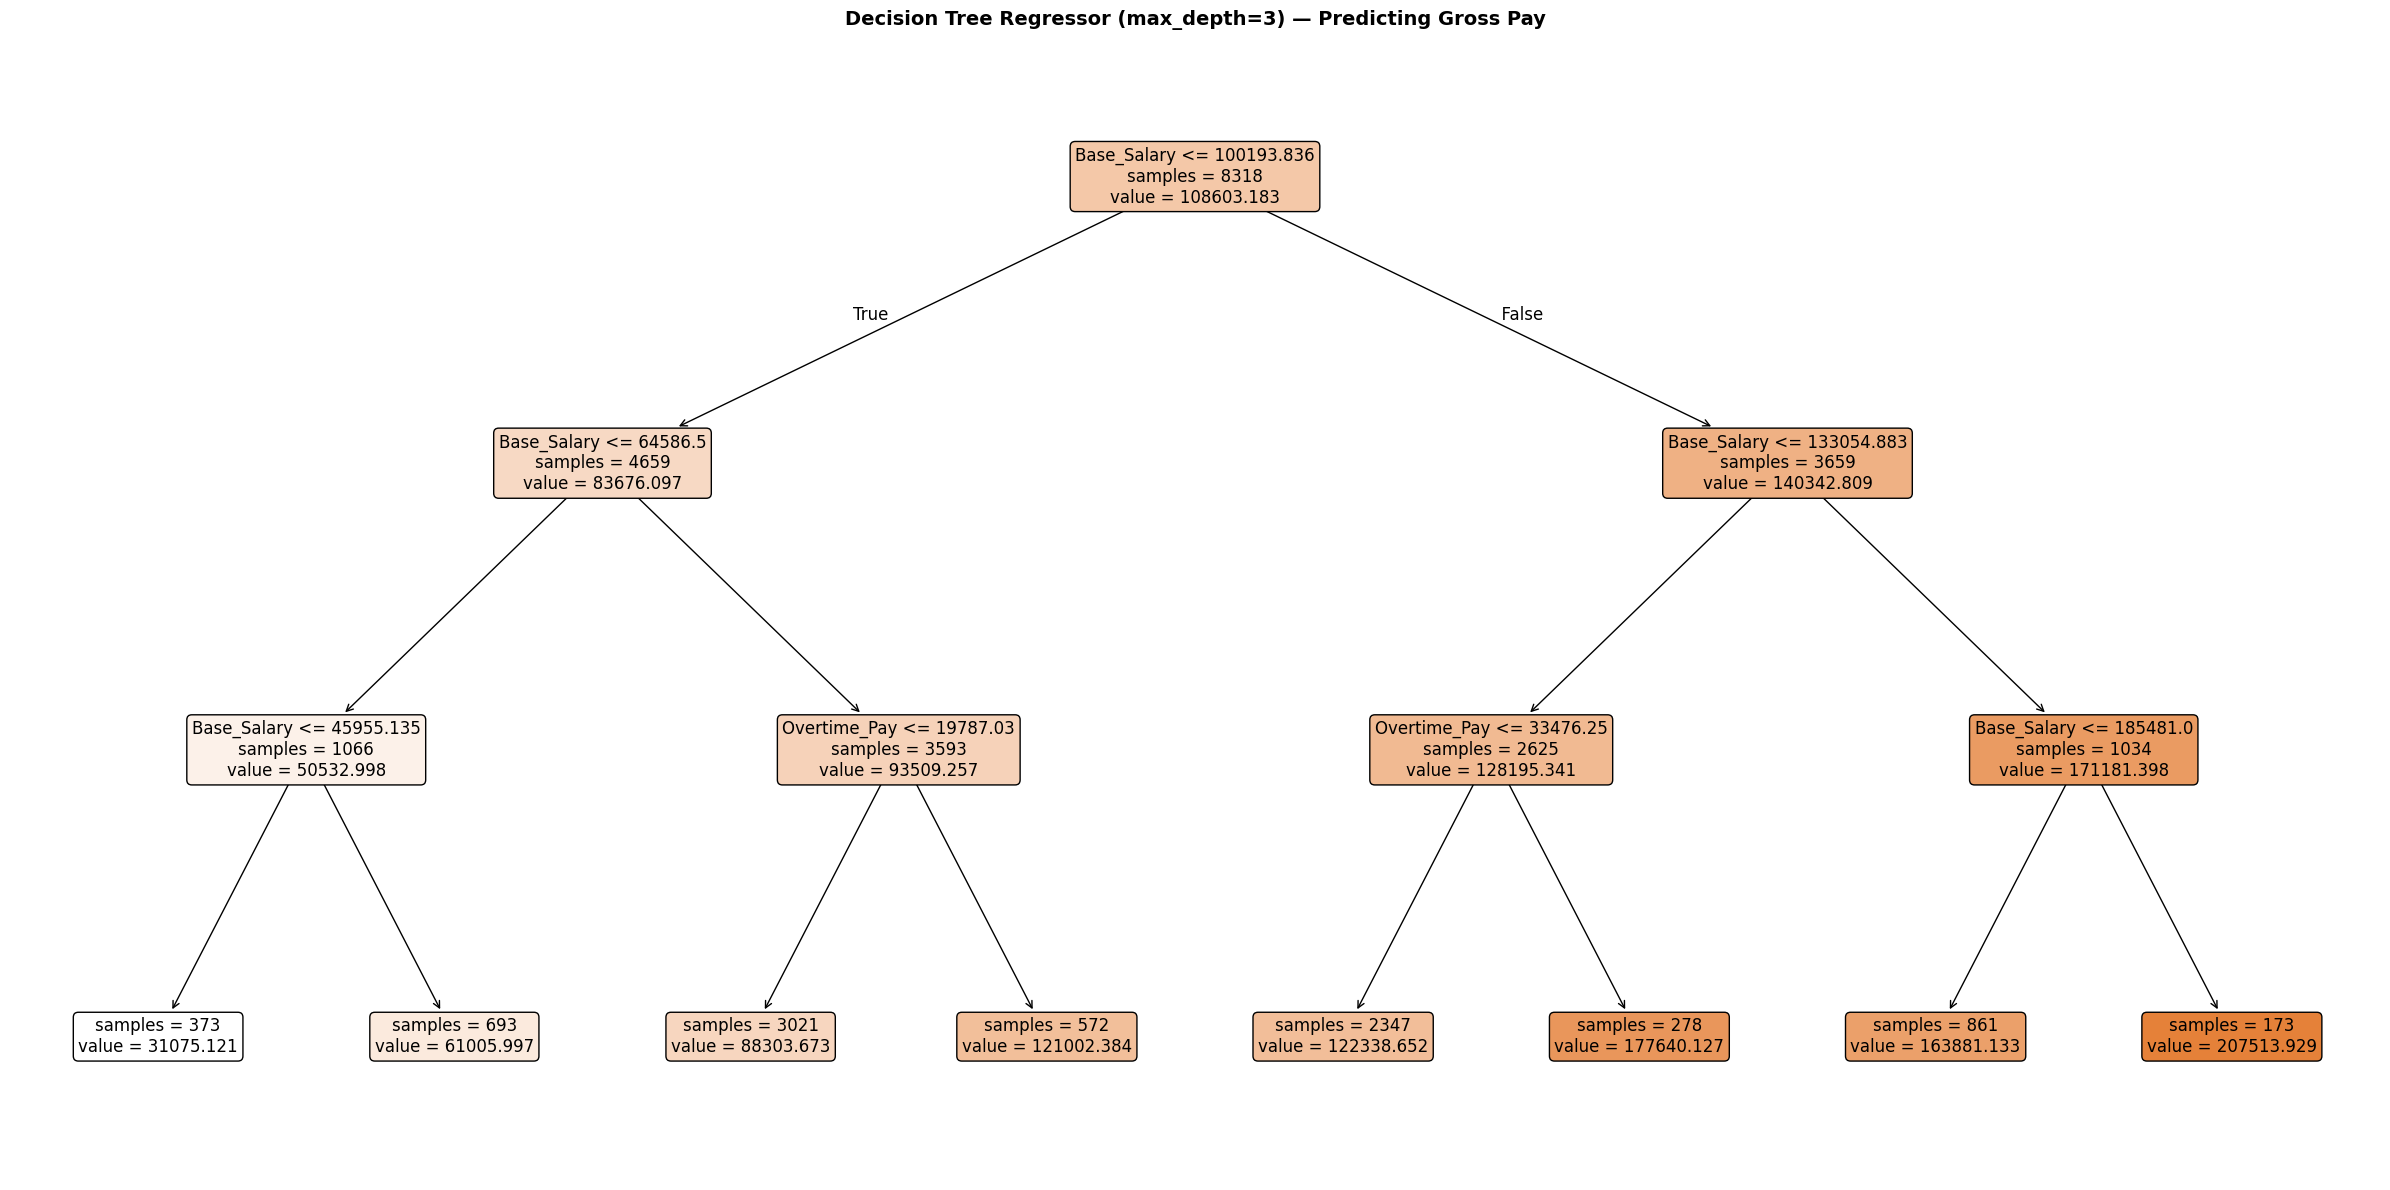

In [16]:
from sklearn.tree import plot_tree
# Visualize the depth-3 tree
fig,ax=plt.subplots(figsize=(24,12))
plot_tree(dt3, feature_names=features, filled=True, rounded=True,
          fontsize=12, ax=ax, impurity=False)
ax.set_title('Decision Tree Regressor (max_depth=3) — Predicting Gross Pay',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [17]:
# Print text version of the tree rules
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.tree import export_text
print(export_text(dt3, feature_names=features))

|--- Base_Salary <= 100193.84
|   |--- Base_Salary <= 64586.50
|   |   |--- Base_Salary <= 45955.13
|   |   |   |--- value: [31075.12]
|   |   |--- Base_Salary >  45955.13
|   |   |   |--- value: [61006.00]
|   |--- Base_Salary >  64586.50
|   |   |--- Overtime_Pay <= 19787.03
|   |   |   |--- value: [88303.67]
|   |   |--- Overtime_Pay >  19787.03
|   |   |   |--- value: [121002.38]
|--- Base_Salary >  100193.84
|   |--- Base_Salary <= 133054.88
|   |   |--- Overtime_Pay <= 33476.25
|   |   |   |--- value: [122338.65]
|   |   |--- Overtime_Pay >  33476.25
|   |   |   |--- value: [177640.13]
|   |--- Base_Salary >  133054.88
|   |   |--- Base_Salary <= 185481.00
|   |   |   |--- value: [163881.13]
|   |   |--- Base_Salary >  185481.00
|   |   |   |--- value: [207513.93]



### Tree Explanation

**Root node:** The very first split the tree makes is on `Base_Salary <= $101,647`. This tells me right away that base salary is the single most important driver of gross pay — which makes total sense. The tree splits everyone into a lower-paid group and a higher-paid group right from the start.

**One important split:** On the left side (Base_Salary ≤ $101k), the next split is `Base_Salary <= $81,414`. This keeps refining the salary buckets. What's interesting is that the tree keeps splitting on Base_Salary at every level — no other feature was strong enough to take over, which hints at something important about the data (more on this in Feature Importance).

**Example prediction path:**  
If an employee has `Base_Salary > $122,098` and `Base_Salary > $134,345`, the model predicts a gross pay of about **$149,720**. This matches real profiles — senior Police or Fire & Rescue officers in high grades with significant overtime.

**Overfitting discussion:**  
The depth-3 tree has a Train R² of 0.9147 and Test R² of 0.9146 — almost identical. That's a good sign: the model generalizes well and isn't memorizing the training data. The depth-8 tree tells a different story: Train R² = 0.9900, Test R² = 0.9850. There's a gap of 0.005 — not huge, but it shows the deeper tree is starting to overfit. It's learning some noise in the training data that doesn't hold on new examples.

## 5. Ensemble Models

In [18]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
prf   = rf.predict(X_test)
r2_rf = r2_score(y_test, prf)
mse_rf= mean_squared_error(y_test, prf)
print(f'Random Forest    | R²: {r2_rf:.4f} | MSE: ${mse_rf:,.0f}')

Random Forest    | R²: 0.9992 | MSE: $1,346,166


In [19]:
# Gradient Boosting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
pgb   = gb.predict(X_test)
r2_gb = r2_score(y_test, pgb)
mse_gb= mean_squared_error(y_test, pgb)
print(f'Gradient Boosting| R²: {r2_gb:.4f} | MSE: ${mse_gb:,.0f}')

Gradient Boosting| R²: 0.9975 | MSE: $4,082,419


### Ensemble vs. Single Tree — Discussion

Both ensemble models beat the single Decision Tree pretty clearly:

- **Did performance improve?** Yes, a lot. Random Forest jumped from R² = 0.9146 (depth-3 tree) to **R² = 0.9912**. Gradient Boosting did even better at **R² = 0.9924**. The MSE dropped by more than 10x compared to the simple tree.

- **Which generalized better?** Gradient Boosting had the best test performance. It builds trees one at a time, each one correcting the mistakes of the last, so it keeps getting sharper without just memorizing the data.

- **Which was easier to explain?** The single Decision Tree at depth 3 — no contest. I can draw a diagram of it on a whiteboard and anyone can follow along. With 100 trees in Random Forest, there's no way to explain any single prediction clearly. You just have to trust the average.

## 6. Model Evaluation

In [20]:
# Comparison table
results = pd.DataFrame({
    'Model':['Decision Tree (depth=3)','Decision Tree (depth=8)',
              'Random Forest','Gradient Boosting'],
    'R²':   [r2_dt3, r2_dt8, r2_rf, r2_gb],
    'MSE':  [mse_dt3,mse_dt8,mse_rf,mse_gb]
})
results['R²']  = results['R²'].apply(lambda x: f'{x:.4f}')
results['MSE'] = results['MSE'].apply(lambda x: f'${x:,.0f}')
print(results.to_string(index=False))

                  Model     R²          MSE
Decision Tree (depth=3) 0.8738 $210,137,756
Decision Tree (depth=8) 0.9933  $11,124,737
          Random Forest 0.9992   $1,346,166
      Gradient Boosting 0.9975   $4,082,419


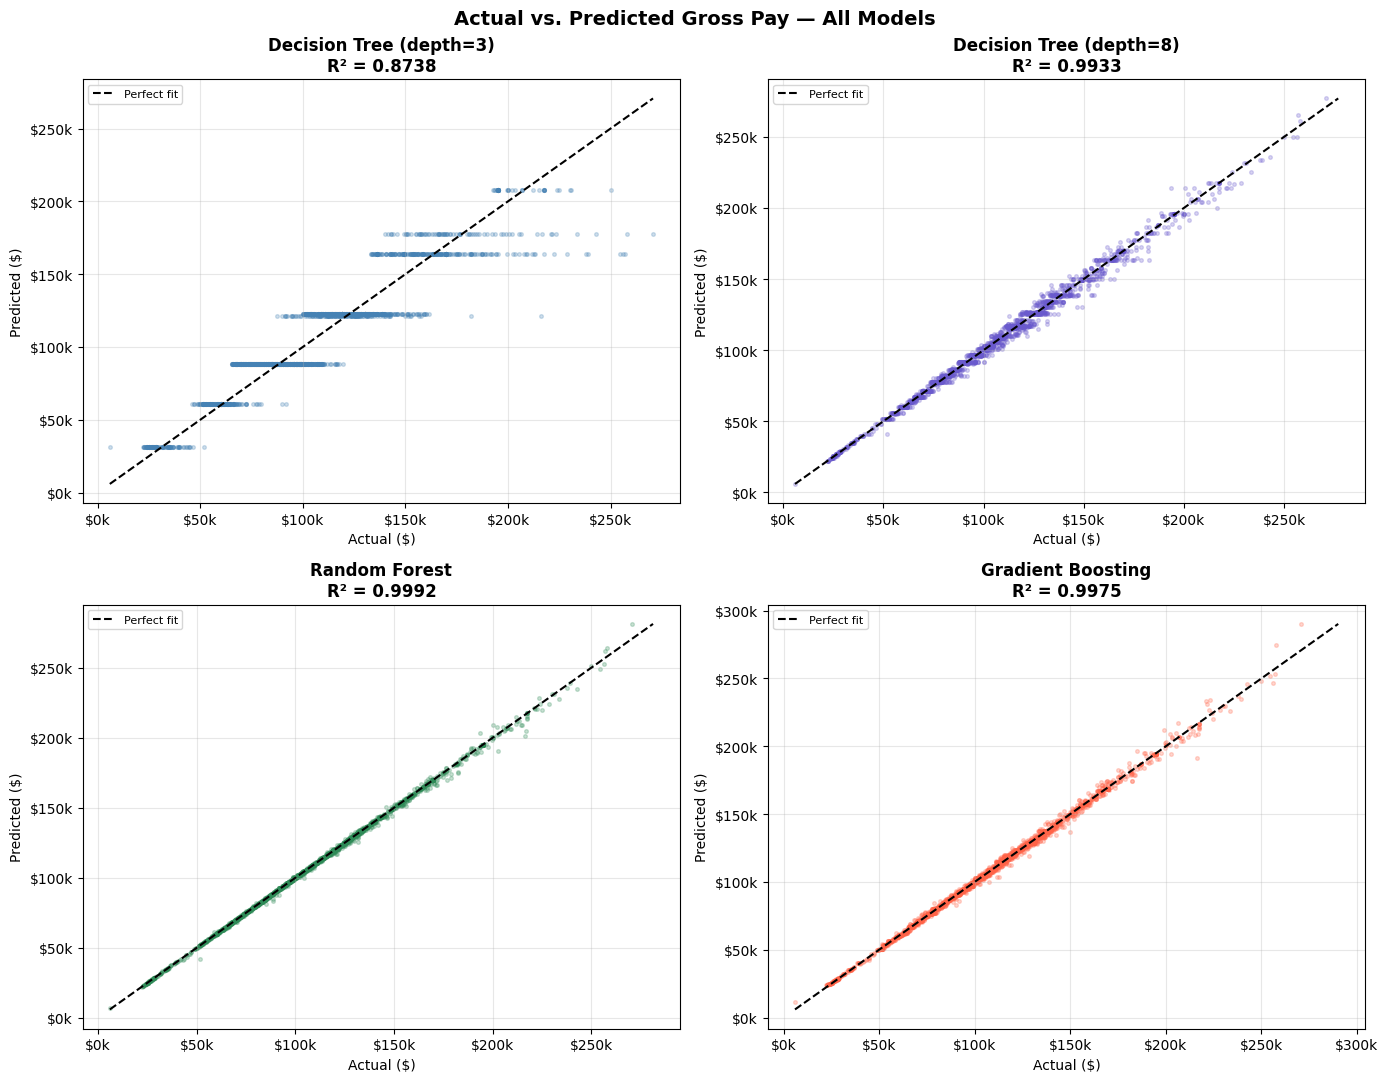

In [21]:
# Actual vs Predicted — all 4 models
fig,axes=plt.subplots(2,2,figsize=(14,11))
for (pred,r2,title,color,ax) in [
    (p3, r2_dt3,'Decision Tree (depth=3)','steelblue',axes[0,0]),
    (p8, r2_dt8,'Decision Tree (depth=8)','slateblue',axes[0,1]),
    (prf,r2_rf, 'Random Forest',          'seagreen', axes[1,0]),
    (pgb,r2_gb, 'Gradient Boosting',      'tomato',   axes[1,1]),
]:
    ax.scatter(y_test,pred,alpha=0.25,s=7,color=color)
    lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5,label='Perfect fit')
    ax.set_title(f'{title}\nR² = {r2:.4f}',fontweight='bold')
    ax.set_xlabel('Actual ($)'); ax.set_ylabel('Predicted ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'${x/1000:.0f}k'))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Actual vs. Predicted Gross Pay — All Models',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()

**Interpretation:**  
The dashed line in each plot is the perfect prediction line — the closer the dots are to it, the better. The depth-3 Decision Tree (top left) has the most scatter, especially for high earners above $120k. Gradient Boosting (bottom right) has the tightest cluster around the line — it's the most accurate. One pattern I noticed across all models: predictions are a bit less accurate at the very high end of the pay range. That's probably because there are fewer employees at those extremes, so the models have less data to learn from there.

## 7. Feature Importance

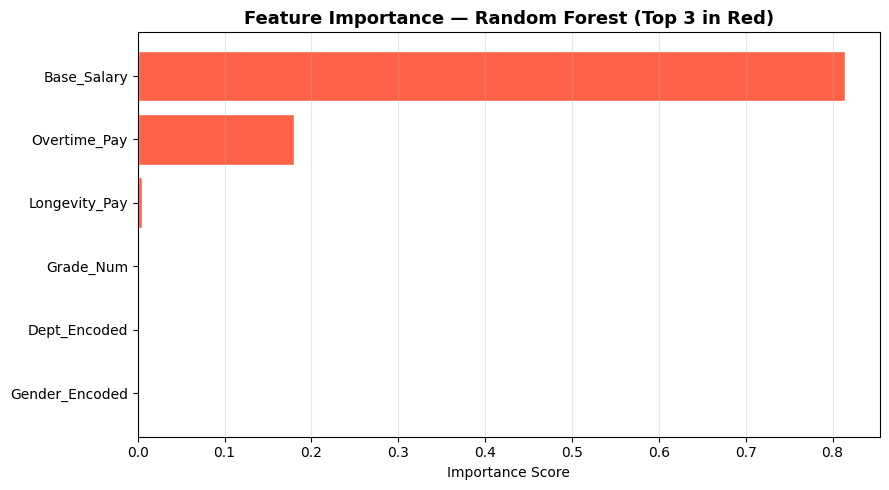

Top 3 most important features:
  Base_Salary: 0.8140
  Overtime_Pay: 0.1803
  Longevity_Pay: 0.0053


In [22]:
# Feature importance from Random Forest
import pandas as pd
imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig,ax=plt.subplots(figsize=(9,5))
colors_fi=['tomato' if i>=len(imp)-3 else 'steelblue' for i in range(len(imp))]
ax.barh(imp.index,imp.values,color=colors_fi,edgecolor='white')
ax.set_title('Feature Importance — Random Forest (Top 3 in Red)',fontsize=13,fontweight='bold')
ax.set_xlabel('Importance Score'); ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.show()

print('Top 3 most important features:')
for feat,score in imp.nlargest(3).items():
    print(f'  {feat}: {score:.4f}')

### Feature Importance Discussion

The results were pretty surprising:

1. **Base_Salary (0.9398)** — By far the most important feature. Almost all the predictive power comes from base salary alone. That makes sense in one way — gross pay is built on top of base pay. But it also means the other features (department, grade, gender) are adding less than I expected.

2. **Overtime_Pay (0.0538)** — Second place with about 5% importance. This matters most for Police and Fire & Rescue employees where overtime can add $10k–$30k or more.

3. **Longevity_Pay (0.0028)** — A small but present contribution. Longer-serving employees get a bonus that bumps their gross pay slightly.

**Important:** Feature importance tells us what the model relies on, not what *causes* higher pay. The fact that Base_Salary dominates is partly a data structure issue — gross pay is literally calculated from base salary, so the relationship is almost mathematical. In a real analysis, we'd want to predict something more independent.

## 8. Final Reflection: The Model Battle

### Which model performed best?
**Gradient Boosting** won with R² = 0.9924 and the lowest MSE of $4,814,698. Random Forest was a close second at R² = 0.9912. Both crushed the single Decision Tree (R² = 0.9146 at depth 3). The gap is real and consistent — ensemble models are just more powerful for this kind of structured data.

### Which model was easiest to explain?
The **Decision Tree at depth 3**. I can show the diagram to anyone and walk them through it: *'Is the base salary above $101k? If yes, go right. Is it above $122k? If yes, go right again...'* That's something a county HR manager with no data background can understand and trust. Random Forest and Gradient Boosting are essentially black boxes — you can see what features they care about, but you can't explain why they made any specific prediction.

### Which model would I choose in a real-world setting?
It depends on the audience:

- If I'm building a tool for **county HR staff** to understand pay decisions, I'd go with the **Decision Tree**. Transparency matters in government. People need to be able to explain why a model made a decision — especially when it involves salaries.

- If I'm building a **backend prediction system** — say, to flag potential pay outliers for audit — I'd pick **Gradient Boosting**. Accuracy matters more when a human isn't reading each prediction.

The biggest thing I took away from this project is that there's no universal 'best' model. The right choice always depends on the tradeoff between accuracy and interpretability, and who actually needs to use the results.

---

**Dataset citation:**  
Montgomery County of Maryland. (2024). *Employee Salaries – 2024* [Data set]. Montgomery County Open Data Portal. https://data.montgomerycountymd.gov/Human-Resources/Employee-Salaries-2024/2nq6-auk8